In [1]:
import numpy as np
import matplotlib.pyplot as plt

import utils

In [2]:
indices = range(56, 60)
names = ["omega", "kessence", "prop", "cugal"]
titles = ["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "K-essence-like", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like"]
aktypes = [1, 2, 4, 3]
mus_all = []

for i, (chain_index, name, aktype, color) in enumerate(zip(indices, names, aktypes, utils.colors)):
    chain = utils.load_chain(chain_index, burn_in=0.8)
    log_a, alpha_B, alpha_K, mus = utils.get_mu_alphas_from_chain(chain, aktype=aktype, num_samples=1_000)
    mus_all.append(mus)

Number of samples = 54091
Number of samples after thinning = 1002
Number of samples = 65645
Number of samples after thinning = 1010
Number of samples = 84546
Number of samples after thinning = 1007
Number of samples = 27462
Number of samples after thinning = 1018


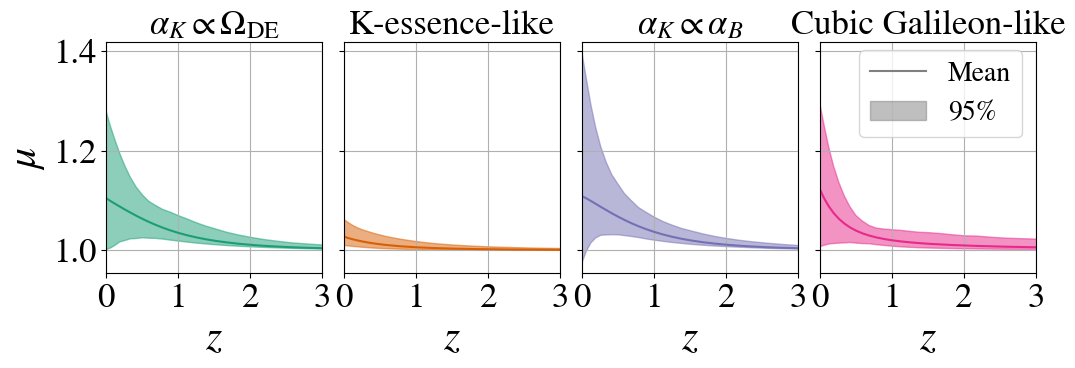

In [3]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, axs = plt.subplots(1, 4, sharey=True, sharex=True, figsize=(12,3), gridspec_kw={"wspace": 0.1})
mean_line = Line2D([], [], ls="-", color="gray", label="Mean")
error_patch = Patch(color="gray", alpha=0.5, label="95%")

for i, color in enumerate(utils.colors[:4]):
    z = 10**-log_a - 1
    axs[i].plot(z, np.mean(mus_all[i], axis=0), color=color)
    axs[i].fill_between(z, np.percentile(mus_all[i], 2.5, axis=0), np.percentile(mus_all[i], 97.5, axis=0), color=color,  alpha=0.5)

axs[0].set_ylabel("$\\mu$", fontsize=30)
for ax, title in zip(axs, titles):
    ax.set_xlim(0, 3)
    ax.grid()
    ax.set_xlabel("$z$", fontsize=30)
    ax.set_title(title, fontsize=25)
    ax.tick_params(axis="both", labelsize=25)
    ax.set_xticks([0, 1, 2, 3])

fig.legend(handles=[mean_line, error_patch], fontsize=20, bbox_to_anchor=(0.9,0.9))

plt.savefig(f"plots/constraint_mu_ds1_subluminal.pdf", bbox_inches="tight")

In [15]:
for chain_index, mus in zip(indices, mus_all):
    mean  = np.mean(mus, axis=0)[-1]
    upper = np.percentile(mus, 50+34, axis=0)[-1] - mean
    lower = mean - np.percentile(mus, 50-34, axis=0)[-1]
    print(f"{chain_index}: \\mu_0 ${mean:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}}$")

56: \mu_0 $1.10^{+0.09}_{-0.08}$
57: \mu_0 $1.03^{+0.01}_{-0.01}$
58: \mu_0 $1.11^{+0.06}_{-0.08}$
59: \mu_0 $1.12^{+0.10}_{-0.09}$
